# Retail Sales Data - Exploratory Data Analysis
---

### Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer behaviour patterns, product performance, and actionable business insights.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
#Import libraries -

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
#Load dataset -

df = pd.read_csv("retail_sales_dataset.csv")

### Initial inspection :
---

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [6]:
df.shape

(1000, 9)

In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [8]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Check missing values :
---

In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

##### Observation

The dataset was checked for missing values using `isnull().sum()`. 
There are no missing values in the dataset, so no missing-value treatment is required.

### Check duplicates :
---

In [11]:
df.duplicated().sum()

np.int64(0)

##### Observation

The dataset contains no duplicate records. Therefore, no duplicate rows were removed.

### Check descriptive statistics :
---

In [12]:
df.select_dtypes(include=np.number).columns

Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')

In [13]:
# Mean

df.select_dtypes(include=np.number).mean()

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [14]:
# Median

df.select_dtypes(include=np.number).median()

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [15]:
# Mode

df.select_dtypes(include=np.number).mode().iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [16]:
# Standard Deviation

df.select_dtypes(include=np.number).std()

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

### Convert the Date column :
---

In [17]:
df["Date"].head()

0    2023-11-24
1    2023-02-27
2    2023-01-13
3    2023-05-21
4    2023-05-06
Name: Date, dtype: object

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
df["Date"].dtype

dtype('<M8[ns]')

In [20]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Year"] = df["Date"].dt.year

### Monthly sales analysis :
---

In [21]:
monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total Amount"].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

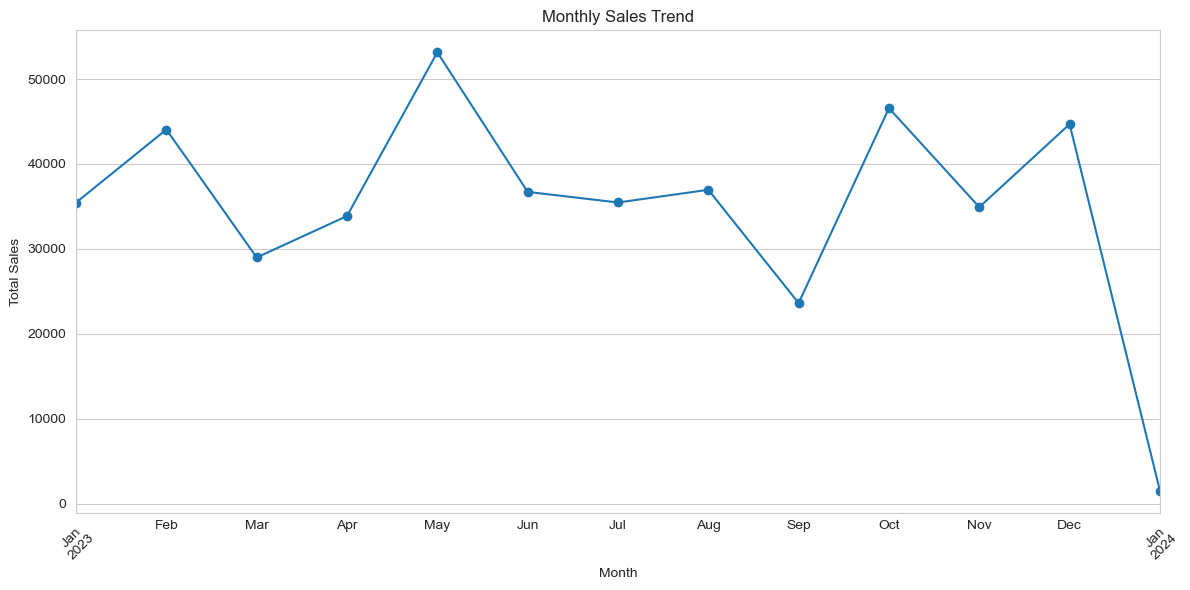

In [22]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observation

The monthly sales trend shows fluctuations in sales over the analyzed period. 
The highest sales occurred during MAY 2023, while the lowest sales occurred during JAN 2024.


### Quarterly sales analysis :
---

In [23]:
quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

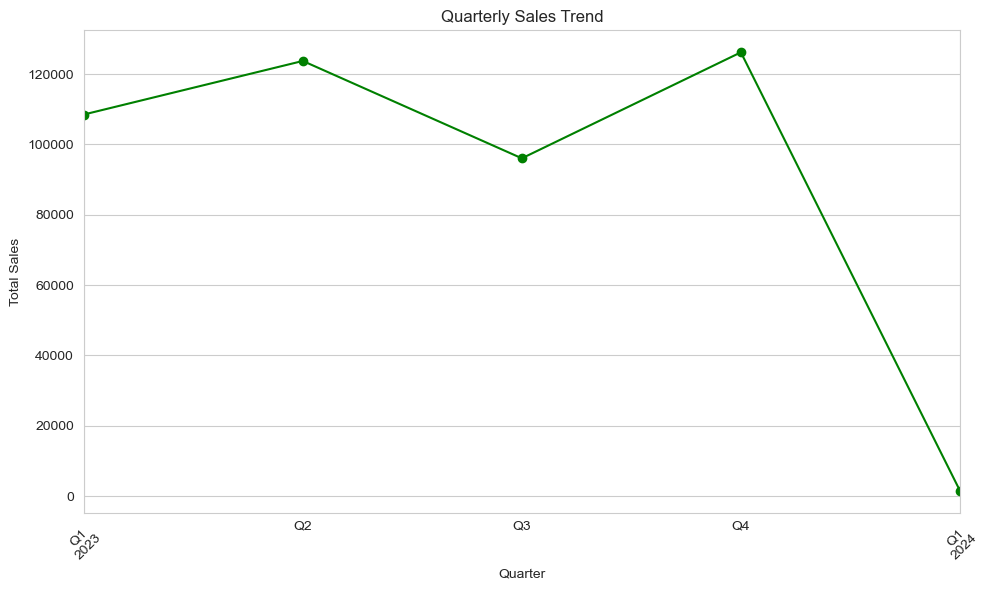

In [24]:
plt.figure(figsize=(10, 6))

quarterly_sales.plot(
    kind="line",
    marker="o",
    color="green"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observation

Quarterly sales show significant fluctuations across the analyzed period.

The strongest quarter was Q4 2023, while the weakest quarter was Q1 2024.

This indicates that the business may experience seasonal variations in sales, with sales being considerably higher during some quarters and a sharp decline at the beginning of 2024.

### Customer demographics :
---

#### 1] Gender analysis :

In [25]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

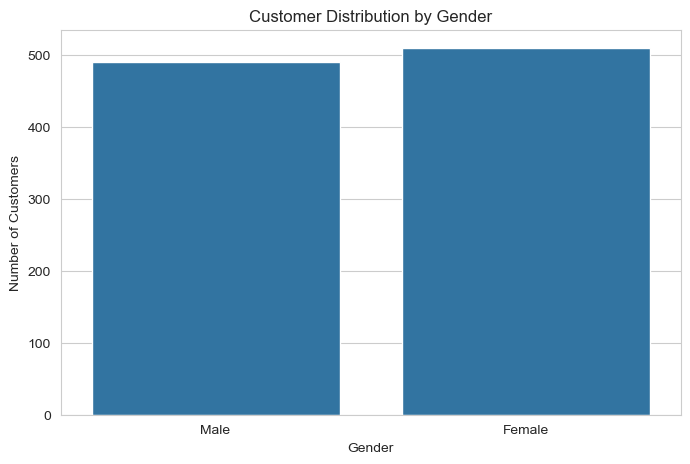

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

##### Observation

The gender distribution shows that FEMALE customers account for the larger share of transactions.

#### 2]Age Analysis :

In [27]:
bins = [0, 18, 25, 35, 45, 55, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [28]:
df["Age Group"].value_counts().sort_index()

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56+         195
Name: count, dtype: int64

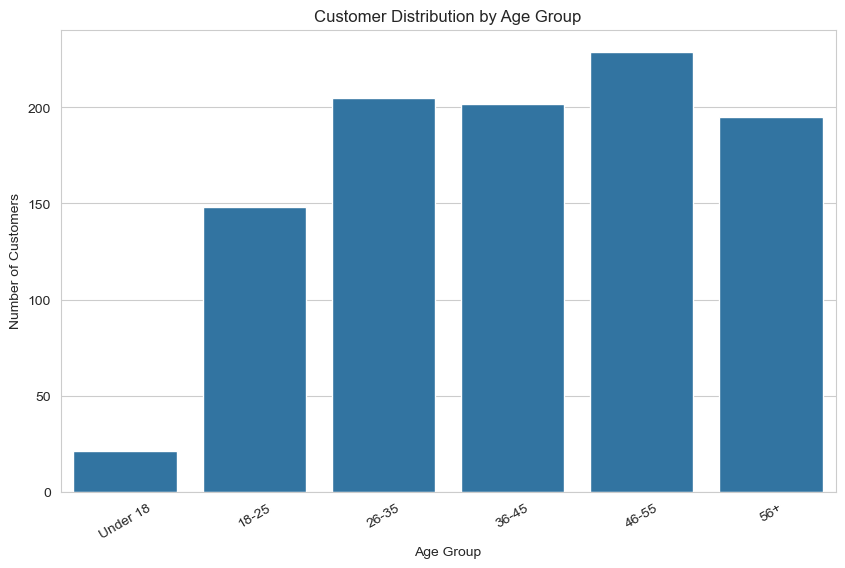

In [29]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Age Group",
    order=labels
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

### Product analysis :
---

In [30]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(
    ascending=False
).head(10)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

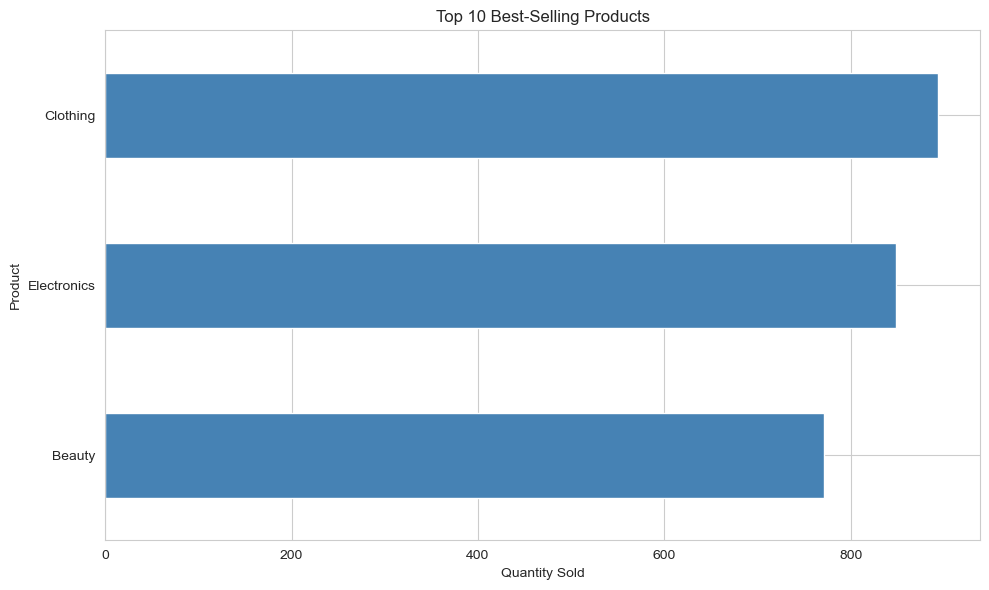

In [31]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Revenue by product category :
---

In [32]:
category_revenue = df.groupby(
    "Product Category"
)["Total Amount"].sum().sort_values(
    ascending=False
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

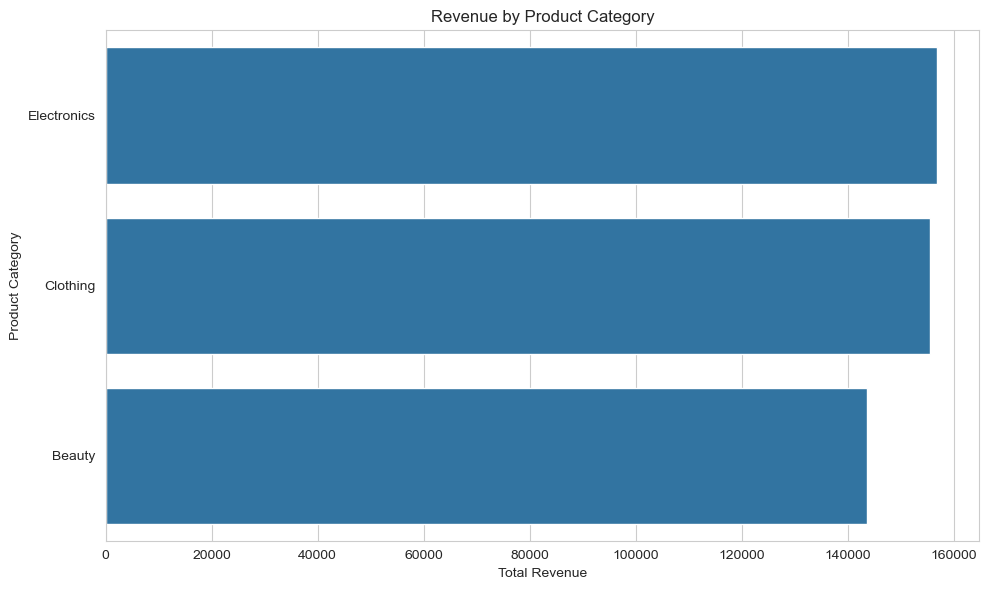

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

##### Observation

The ELECTRONICS category generates the highest revenue, while BEAUTY generates the lowest.

### Correlation heatmap :
---

In [34]:
numeric_data = df.select_dtypes(include=np.number)

In [35]:
correlation = numeric_data.corr()

correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Month,Quarter,Year
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034,0.047538,0.038435,-0.010855
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568,-0.000640,-0.000837,0.023269
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707,-0.021803,-0.020411,-0.020324
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925,-0.008161,-0.005834,0.020097
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000,-0.005197,-0.001605,0.024714
Month,0.047538,-0.000640,-0.021803,-0.008161,-0.005197,1.000000,0.972875,-0.071981
Quarter,0.038435,-0.000837,-0.020411,-0.005834,-0.001605,0.972875,1.000000,-0.061028
Year,-0.010855,0.023269,-0.020324,0.020097,0.024714,-0.071981,-0.061028,1.000000


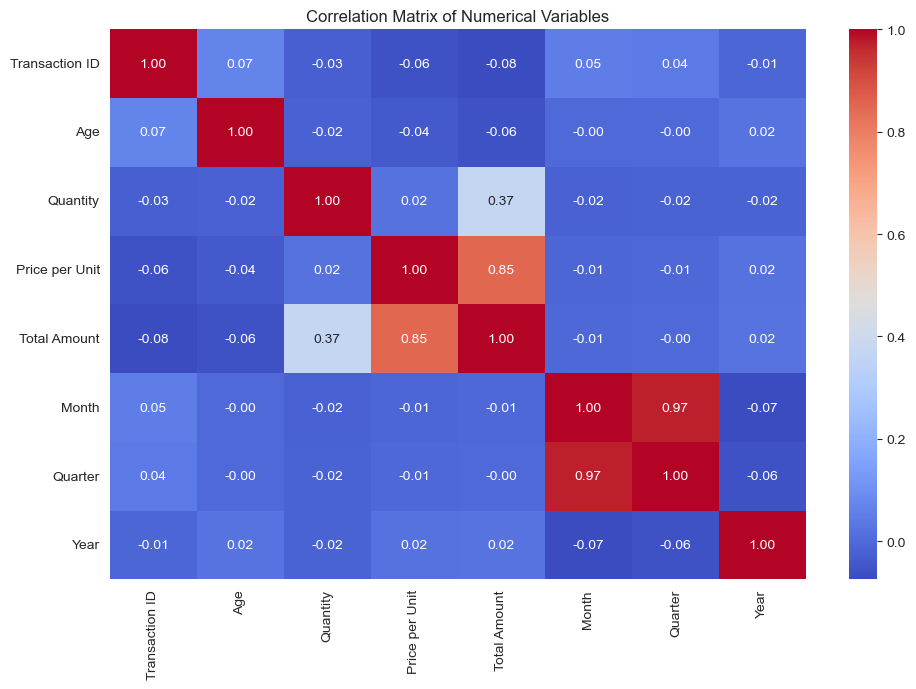

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

##### Observation

The correlation heatmap indicates a strong positive relationship between Price per Unit and Total Amount.

This is expected because the total transaction amount is calculated based on the price per unit and the quantity purchased. Therefore, transactions with higher-priced items generally result in higher total sales amounts.

Age shows a very weak negative relationship with total sales, suggesting that customer age has little linear relationship with the amount spent in a transaction.

### Additional Visualization :

#### Revenue per transaction 
---

In [37]:
revenue_per_age_group = df.groupby(
    "Age Group",
    observed=True
).agg(
    Total_Revenue=("Total Amount", "sum"),
    Transactions=("Transaction ID", "count")
)

revenue_per_age_group["Revenue_per_Transaction"] = (
    revenue_per_age_group["Total_Revenue"] /
    revenue_per_age_group["Transactions"]
)

revenue_per_age_group

,Total_Revenue,Transactions,Revenue_per_Transaction
Age Group,,,
Under 18,11215,21,534.047619
18-25,73335,148,495.506757
26-35,98480,205,480.390244
36-45,91870,202,454.801980
46-55,100690,229,439.694323
56+,80410,195,412.358974


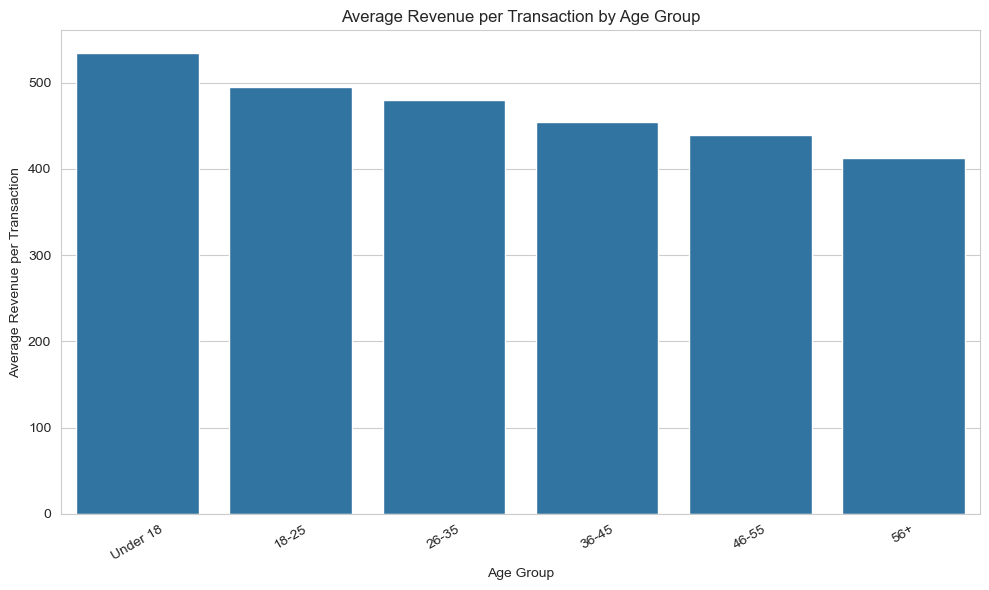

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_per_age_group.reset_index(),
    x="Age Group",
    y="Revenue_per_Transaction"
)

plt.title("Average Revenue per Transaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Revenue per Transaction")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Business Recommendations :
---

#### 1. Focus on high-performing product categories

Prioritize inventory planning and promotional campaigns for the highest-revenue product category to maximize sales opportunities and reduce the risk of stockouts. The business should also monitor demand for this category regularly to ensure sufficient inventory during high-sales periods.

---

#### 2. Target high-value customer segments

Develop targeted marketing campaigns for the age group that generates the highest revenue. Personalized offers, loyalty incentives, and relevant promotions can be used to encourage repeat purchases and increase customer value.

---

#### 3. Plan around seasonal sales trends

Use historical monthly and quarterly sales patterns to improve inventory and promotional planning. Inventory and marketing activity can be increased ahead of high-sales periods, while targeted promotions can be introduced during weaker periods to help improve sales performance.

---

#### 4. Optimize pricing and product mix

The strong positive relationship between price per unit and total transaction amount suggests that higher-priced products contribute significantly to transaction revenue. The business should identify high-value products that customers are willing to purchase and consider appropriate product bundling or premium offerings to increase average transaction value.


### Conclusion :
---

This exploratory data analysis provided insights into retail sales performance, customer demographics, product categories, and sales trends over time.

The analysis identified key patterns in monthly and quarterly sales, customer age and gender distribution, and product/category performance.

The findings suggest that the business can improve performance by focusing on high-performing product categories, targeting valuable customer segments, and using historical sales trends to improve inventory and promotional planning.

Overall, the analysis demonstrates how data-driven decision-making can help the business improve sales performance, understand customers, and optimize marketing and inventory strategies.